# xBD — From-scratch Siamese CNN

This notebook trains the compact change-detection CNN from **random initialization**. It uses the same extracted pre/post building patches and split assignment as the pretrained ResNet-18 experiment, so the comparison isolates the effect of ImageNet pretraining.

The model is selected solely on validation macro-F1, restored from its best checkpoint, and then evaluated once on the in-distribution and wildfire test sets.

**Before running:** start Jupyter from the repository root and generate `work-pretrained/patches` with `data_cleaning_eda.ipynb` (the shared data-preparation pipeline). Those arrays contain data only—this CNN never loads pretrained weights.

## Task 1: Setup and Shared Data

This section prepares everything the experiment needs before any modelling: it checks the runtime, fixes every routine choice in a single configuration cell, and loads the pre/post patch arrays that are shared with the pretrained ResNet-18 notebook. Reusing the exact same inputs is what makes the later "pretrained vs. from scratch" comparison fair.

### 1.1 Environment and imports

Fail early if a required package is missing, then import the full training stack in one place and print the Torch version and whether a GPU is visible.

In [6]:
import importlib.util
REQUIRED = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'torch': 'torch', 'sklearn': 'scikit-learn'}
missing = [package for module, package in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    raise ImportError('Missing packages: ' + ', '.join(missing) + '\nInstall the local requirements and PyTorch; see docs/local_setup.md.')

import json, random, time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_fscore_support, roc_auc_score
from torch.utils.data import DataLoader, Dataset

print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())

torch 2.12.0.dev20260408+cu128 | CUDA available: True


### 1.2 Run configuration

All routine choices live here: paths, reproducibility seed, training budget, and early-stopping patience. Changing this one cell is enough for an ordinary run. `RESUME` continues a previously interrupted run.

In [7]:
# Configuration. Change only this cell for ordinary runs.
PROJECT_ROOT_OVERRIDE = None  # e.g. r'D:\\projects\\satellite-disaster-damage-mapping'
PATCH_DIR_OVERRIDE = None
OUTPUT_DIR_OVERRIDE = None
EPOCHS, BATCH_SIZE, PATIENCE = 50, 128, 8
LEARNING_RATE, WEIGHT_DECAY, SEED = 1e-3, 1e-4, 42
RESUME = False

CLASSES = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD = np.array([0.229, 0.224, 0.225], np.float32)

def find_project_root():
    candidates = [Path(PROJECT_ROOT_OVERRIDE)] if PROJECT_ROOT_OVERRIDE else []
    here = Path.cwd().resolve()
    candidates += [here, *here.parents]
    for candidate in candidates:
        if (candidate / '.git').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find work-pretrained/patches. Run from the project root or set PROJECT_ROOT_OVERRIDE.')
PATCH_DIR = Path(PATCH_DIR_OVERRIDE) if PATCH_DIR_OVERRIDE else PROJECT_ROOT / 'work-pretrained' / 'patches'
OUTPUT_DIR = Path(OUTPUT_DIR_OVERRIDE) if OUTPUT_DIR_OVERRIDE else PROJECT_ROOT / 'work-scratch'
print('patches:', PATCH_DIR)
print('outputs:', OUTPUT_DIR)

patches: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-pretrained\patches
outputs: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-scratch | mode: full


### 1.3 Shared patch inputs

The pretrained notebook performs the expensive crop extraction once and writes memory-mapped pre/post arrays plus a manifest. This notebook reuses those exact files so the two models see identical data and splits.

The preflight below verifies array layout, dtypes, manifest indices, labels, and all four split names *before* any checkpoint or result file is written, so a bad input fails fast instead of halfway through training.

In [9]:
# Input preflight: fail before allocating a model or writing any output.
manifest_path, pre_path, post_path = (PATCH_DIR / 'manifest.csv', PATCH_DIR / 'pre.npy', PATCH_DIR / 'post.npy')
missing_inputs = [str(path) for path in (manifest_path, pre_path, post_path) if not path.is_file()]
if missing_inputs:
    raise FileNotFoundError('Missing required patch inputs:\n  ' + '\n  '.join(missing_inputs))

manifest = pd.read_csv(manifest_path)
required_columns = {'row', 'label', 'split'}
if absent := required_columns - set(manifest.columns):
    raise ValueError(f'manifest.csv is missing columns: {sorted(absent)}')
expected_splits = {'train', 'val', 'test_id', 'test_ood'}
actual_splits = set(manifest['split'].dropna().unique())
if actual_splits != expected_splits:
    raise ValueError(f'Expected splits {sorted(expected_splits)}, found {sorted(actual_splits)}')
if manifest.empty or manifest[['row', 'label', 'split']].isna().any().any():
    raise ValueError('manifest.csv is empty or has missing row, label, or split values')
for column in ('row', 'label'):
    values = pd.to_numeric(manifest[column], errors='coerce')
    if values.isna().any() or not np.isfinite(values).all() or not np.equal(values, np.floor(values)).all():
        raise TypeError(f'manifest {column} values must be finite integers')
    manifest[column] = values.astype(np.int64)
if not manifest['label'].between(0, len(CLASSES) - 1).all():
    raise ValueError(f'labels must be in [0, {len(CLASSES) - 1}]')

pre_array, post_array = np.load(pre_path, mmap_mode='r'), np.load(post_path, mmap_mode='r')
if pre_array.shape != post_array.shape:
    raise ValueError(f'pre/post array shapes differ: {pre_array.shape} versus {post_array.shape}')
if pre_array.ndim != 4 or pre_array.shape[-1] != 3:
    raise ValueError(f'Expected arrays shaped (N, H, W, 3), got {pre_array.shape}')
if pre_array.dtype != np.uint8 or post_array.dtype != np.uint8:
    raise TypeError(f'Expected uint8 arrays, got {pre_array.dtype} and {post_array.dtype}')
if manifest['row'].min() < 0 or manifest['row'].max() >= len(pre_array) or manifest['row'].duplicated().any():
    raise ValueError('manifest row values must be unique and within the patch-array bounds')
if any((manifest['split'] == split).sum() == 0 for split in expected_splits):
    raise ValueError('Every expected split must contain at least one sample')
print('Preflight passed:', pre_array.shape, pre_array.dtype)
display(manifest.groupby('split').size().reindex(['train', 'val', 'test_id', 'test_ood']).rename('patches').to_frame())

Preflight passed: (135262, 64, 64, 3) uint8


,patches
split,
train,72916
val,20446
test_id,27273
test_ood,14627


## Task 2: Data Pipeline and Model

This section defines how a stored patch pair becomes a training tensor and what network consumes it. Definitions come first (dataset class, model class), then the concrete objects are built step by step — runtime, loaders, and the class-weight vector — so each piece can be inspected on its own before training starts.

### 2.1 Patch-pair dataset and augmentation

Each example is a pair of aligned 64x64 RGB patches: the same building footprint before and after the disaster. `PatchPairDataset` reads both patches from the memory-mapped arrays, applies ImageNet normalisation, and returns `(pre, post, label)`.

During training only, flips, 90-degree rotations, and a mild brightness jitter are applied **identically to both patches in a pair**. Applying the same geometric transform to pre and post preserves the change signal the model has to detect; validation and test patches are never augmented.

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class PatchPairDataset(Dataset):
    def __init__(self, frame, patch_dir, augment=False):
        self.rows = frame.row.to_numpy(np.int64)
        self.labels = frame.label.to_numpy(np.int64)
        self.patch_dir = Path(patch_dir)
        self.augment = augment
        self._pre = None
        self._post = None

    def __len__(self):
        return len(self.rows)

    def arrays(self):
        if self._pre is None:
            self._pre = np.load(self.patch_dir / 'pre.npy', mmap_mode='r')
            self._post = np.load(self.patch_dir / 'post.npy', mmap_mode='r')
        return self._pre, self._post

    def normalize(self, image):
        image = (image.astype(np.float32) / 255.0 - MEAN) / STD
        return torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1)))

    def __getitem__(self, index):
        pre_data, post_data = self.arrays()
        row = self.rows[index]
        pre = np.asarray(pre_data[row])
        post = np.asarray(post_data[row])
        if self.augment:
            if np.random.rand() < 0.5:
                pre, post = pre[:, ::-1], post[:, ::-1]
            if np.random.rand() < 0.5:
                pre, post = pre[::-1], post[::-1]
            turns = np.random.randint(4)
            if turns:
                pre, post = np.rot90(pre, turns), np.rot90(post, turns)
            if np.random.rand() < 0.3:
                gain = np.float32(np.random.uniform(0.85, 1.15))
                pre = np.clip(pre.astype(np.float32) * gain, 0, 255).astype(np.uint8)
                post = np.clip(post.astype(np.float32) * gain, 0, 255).astype(np.uint8)
        return self.normalize(pre), self.normalize(post), int(self.labels[index])

### 2.2 Siamese CNN architecture

The network is trained from random initialisation — it never loads pretrained weights.

**Encoder** (shared weights, applied to both `pre` and `post`):
- Four `ConvBlock`s with channel widths 32 -> 64 -> 128 -> 256
- Each `ConvBlock` = two 3x3 conv layers (BatchNorm + ReLU after each), then 2x2 max-pool
- `AdaptiveAvgPool2d(1)` + `Flatten` -> a 256-d embedding per patch

**Change head:**
- Combine the two embeddings as `[pre, post, |pre - post|]` (768-d) so the classifier sees both absolute appearance and the change between dates
- `Linear(768 -> 256)` -> ReLU -> `Dropout(0.4)` -> `Linear(256 -> 4)`

**Output:** logits over the four damage classes `no-damage`, `minor-damage`, `major-damage`, `destroyed`.

In [ ]:
class ConvBlock(nn.Sequential):
    """Two 3x3 convolutions (BatchNorm + ReLU each) followed by 2x2 max-pooling."""
    def __init__(self, in_channels, out_channels):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )


class SiameseScratchCNN(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()
        # Shared encoder: run on the pre and the post patch with the same weights.
        self.encoder = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        # Classifier head: sees pre, post, and their absolute difference.
        self.head = nn.Sequential(
            nn.Linear(256 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, pre, post):
        pre_features = self.encoder(pre)
        post_features = self.encoder(post)
        change_features = torch.abs(pre_features - post_features)  # date-to-date change signal
        return self.head(torch.cat([pre_features, post_features, change_features], dim=1))


### 2.3 Runtime: device, seeds, and checkpoint paths

Seed every RNG, pick the device, enable mixed precision when CUDA is available, and create the output and checkpoint folders. No model exists yet, so the runtime can be checked before any training work begins.

In [ ]:
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = device.type == 'cuda'
if amp_enabled:
    torch.backends.cudnn.benchmark = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_dir = OUTPUT_DIR / 'checkpoints'
checkpoint_dir.mkdir(exist_ok=True)
best_path = checkpoint_dir / 'best.pt'
last_path = checkpoint_dir / 'last.pt'

print(f'device: {device}')
print(f'CUDA mixed precision: {amp_enabled}')
print(f'outputs: {OUTPUT_DIR}')

### 2.4 Dataset and loader objects

Instantiate one `PatchPairDataset` per split (augmentation on for `train` only) and wrap each in a `DataLoader`. The sanity check pulls one training batch and prints the tensor shapes so a shape bug surfaces here rather than inside the training loop.

In [ ]:
datasets = {
    split: PatchPairDataset(
        manifest[manifest.split.eq(split)],
        PATCH_DIR,
        augment=split == 'train',
    )
    for split in ['train', 'val', 'test_id', 'test_ood']
}
print('Dataset sizes:')
for split, dataset in datasets.items():
    print(f'  {split}: {len(dataset):,} patches')

In [ ]:
loaders = {
    split: DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=split == 'train',
        num_workers=0,
        pin_memory=amp_enabled,
    )
    for split, dataset in datasets.items()
}

pre_batch, post_batch, label_batch = next(iter(loaders['train']))
print(f'pre batch: {tuple(pre_batch.shape)}')
print(f'post batch: {tuple(post_batch.shape)}')
print(f'label batch: {tuple(label_batch.shape)}')
print(f'labels in first batch: {label_batch.tolist()[:10]}')

### 2.5 Class-weighted loss weights

The damage classes are heavily imbalanced — most patches are `no-damage`. Inverse-frequency weights are computed from the **training labels only** and passed to the cross-entropy loss so the rarer, more severe classes are not ignored. Validation and test labels play no part in this.

In [ ]:
train_labels = datasets['train'].labels
class_counts = np.bincount(train_labels, minlength=len(CLASSES)).astype(float)
class_weights = class_counts.sum() / (len(CLASSES) * np.maximum(class_counts, 1))

class_weight_table = pd.DataFrame({
    'class': CLASSES,
    'train_patches': class_counts.astype(int),
    'share_percent': 100 * class_counts / class_counts.sum(),
    'loss_weight': class_weights,
})
display(class_weight_table.round({'share_percent': 2, 'loss_weight': 3}))
print('Weights use training labels only; validation and test labels are not used.')

## Task 3: Training

The model is trained with a class-weighted cross-entropy loss, AdamW, and a cosine learning-rate schedule. After every epoch it is evaluated on the validation split; the checkpoint with the best validation macro-F1 is kept, and training stops early once macro-F1 has not improved for `PATIENCE` epochs.

### 3.1 Instantiate the model

Build the `SiameseScratchCNN`, move it to the device, and print the layer stack and parameter count.

In [ ]:
model = SiameseScratchCNN(num_classes=len(CLASSES)).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f'Parameter count: {parameter_count:,}')

### 3.2 Loss, optimizer, and scheduler

**Loss:** cross-entropy with the inverse-frequency class weights from Section 2.5.

**Optimizer:** AdamW
- learning rate: `1e-3`
- weight decay: `1e-4`

**Schedule:** `CosineAnnealingLR` over the full epoch budget, decaying the learning rate smoothly toward zero.

**Mixed precision:** a `GradScaler` is used when training on CUDA.

In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

print(f'learning rate: {LEARNING_RATE}')
print(f'weight decay: {WEIGHT_DECAY}')
print(f'epochs: {EPOCHS}')
print(f'patience: {PATIENCE}')

### 3.3 Evaluation helper

One function reused for validation during training and for the final held-out evaluation. It returns the mean loss plus stacked true labels, predictions, and softmax probabilities for a loader.

In [ ]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    count = 0
    truths, predictions, probabilities = [], [], []
    for pre, post, labels in loader:
        pre = pre.to(device, non_blocking=True)
        post = post.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(pre, post)
            loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        count += labels.size(0)
        truths.append(labels.cpu().numpy())
        predictions.append(logits.argmax(1).cpu().numpy())
        probabilities.append(torch.softmax(logits.float(), 1).cpu().numpy())
    if count == 0:
        raise RuntimeError('Evaluation loader produced no batches')
    return total_loss / count, np.concatenate(truths), np.concatenate(predictions), np.concatenate(probabilities)

print('Evaluation helper ready.')

### 3.4 Training loop with early stopping

`train_one_run()` runs the epoch loop: forward/backward under autocast, `scheduler.step()`, then a validation pass. Two checkpoints are written every epoch — `best.pt` (updated only when validation macro-F1 improves) and `last.pt` (a full resumable state). Training breaks once `PATIENCE` stale epochs pass, and the best checkpoint is reloaded before the function returns.

In [ ]:
def train_model():
    history = []
    start_epoch = 1
    best_f1 = -1.0
    best_epoch = 0
    stale = 0

    if RESUME:
        if not last_path.is_file():
            raise FileNotFoundError(f'RESUME=True but checkpoint is missing: {last_path}')
        state = torch.load(last_path, map_location=device, weights_only=False)
        model.load_state_dict(state['model'])
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        scaler.load_state_dict(state['scaler'])
        history = state['history']
        start_epoch = state['epoch'] + 1
        best_f1 = state['best_f1']
        best_epoch = state['best_epoch']
        stale = state['stale']
        print(f'Resuming after epoch {start_epoch - 1}')

    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        started = time.perf_counter()
        running_loss = 0.0
        seen = 0
        for pre, post, labels in loaders['train']:
            pre = pre.to(device, non_blocking=True)
            post = post.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                loss = criterion(model(pre, post), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * labels.size(0)
            seen += labels.size(0)

        scheduler.step()
        val_loss, y_true, y_pred, _ = evaluate(loaders['val'])
        record = {
            'epoch': epoch,
            'train_loss': running_loss / max(seen, 1),
            'val_loss': val_loss,
            'val_acc': float((y_true == y_pred).mean()),
            'val_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'lr': scheduler.get_last_lr()[0],
            'seconds': time.perf_counter() - started,
        }
        history.append(record)
        improved = record['val_f1'] > best_f1
        if improved:
            best_f1 = record['val_f1']
            best_epoch = epoch
            stale = 0
            torch.save({
                'state_dict': model.state_dict(),
                'arch': 'SiameseScratchCNN-32-64-128-256',
                'classes': CLASSES,
                'best_epoch': best_epoch,
                'best_val_macro_f1': best_f1,
                'parameter_count': parameter_count,
            }, best_path)
        else:
            stale += 1
        torch.save({
            'epoch': epoch,
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'scaler': scaler.state_dict(),
            'history': history,
            'best_f1': best_f1,
            'best_epoch': best_epoch,
            'stale': stale,
        }, last_path)
        pd.DataFrame(history).to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
        print(
            f"epoch {epoch:02d}/{EPOCHS} "
            f"train={record['train_loss']:.4f} val={val_loss:.4f} "
            f"acc={record['val_acc']:.4f} macroF1={record['val_f1']:.4f}"
            f"{' <- best' if improved else ''}"
        )
        if stale >= PATIENCE:
            print(f'Early stop after {PATIENCE} stale epochs')
            break

    if not best_path.is_file():
        raise RuntimeError('No best checkpoint was written')
    best = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(best['state_dict'])
    print(f"Restored best checkpoint: epoch={best['best_epoch']}, val macro-F1={best['best_val_macro_f1']:.4f}")
    return history, best_epoch, best_f1

print('Training function ready.')

### 3.5 Run training and restore the best checkpoint

Run the full training loop. Each per-epoch line shows train loss, validation loss, accuracy, and macro-F1, with `<- best` marking a new best checkpoint. When the loop ends, `model` holds the best weights and `best_epoch` / `best_f1` record where they came from.

In [ ]:
history, best_epoch, best_f1 = train_one_run()


device=cuda | parameters=1,371,108 | class weights=[0.33, 2.379, 2.91, 4.919]
epoch 01/50 train=1.0477 val=0.9120 acc=0.6396 macroF1=0.4696 <- best
epoch 02/50 train=0.8895 val=0.8700 acc=0.6279 macroF1=0.4833 <- best
epoch 03/50 train=0.8342 val=0.7282 acc=0.7218 macroF1=0.5470 <- best
epoch 04/50 train=0.7998 val=0.7667 acc=0.6988 macroF1=0.5267
epoch 05/50 train=0.7773 val=0.7378 acc=0.7676 macroF1=0.5648 <- best
epoch 06/50 train=0.7531 val=0.6915 acc=0.7243 macroF1=0.5541
epoch 07/50 train=0.7358 val=0.7157 acc=0.7165 macroF1=0.5540
epoch 08/50 train=0.7181 val=0.6593 acc=0.7677 macroF1=0.5915 <- best
epoch 09/50 train=0.7016 val=0.6915 acc=0.7048 macroF1=0.5563
epoch 10/50 train=0.6922 val=0.6428 acc=0.7770 macroF1=0.5996 <- best
epoch 11/50 train=0.6758 val=0.6339 acc=0.7341 macroF1=0.5826
epoch 12/50 train=0.6648 val=0.6512 acc=0.7236 macroF1=0.5705
epoch 13/50 train=0.6555 val=0.6172 acc=0.7373 macroF1=0.5912
epoch 14/50 train=0.6424 val=0.6063 acc=0.7878 macroF1=0.6110 <- bes

## Task 4: Evaluation and Comparison

The restored best model is evaluated once on the validation, in-distribution test, and wildfire out-of-distribution test splits. This section saves the reproducible metric artifacts, inspects individual predictions, and compares in-distribution against out-of-distribution behaviour.

### 4.1 Held-out metrics and saved artifacts

Evaluate the best weights on `val`, `test_id`, and `test_ood`. For each split this records overall accuracy, macro-F1, weighted-F1, and macro ROC-AUC, plus per-class precision/recall/F1 and a confusion matrix. Everything is written to CSV under `work-scratch/`, the learning curves are plotted and saved, and the run configuration is dumped to `run_config.json`.

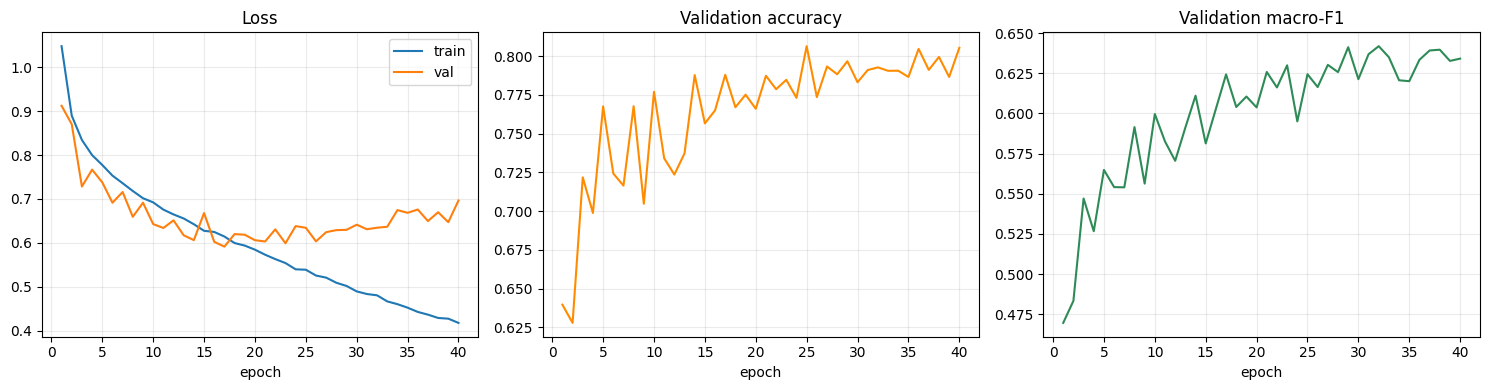

,model,split,n,accuracy,macro_F1,weighted_F1,macro_ROC_AUC
0,from_scratch_siamese_cnn,val,20446,0.7928,0.6419,0.8069,0.9188
1,from_scratch_siamese_cnn,test_id,27273,0.7914,0.6483,0.8032,0.9142
2,from_scratch_siamese_cnn,test_ood,14627,0.6874,0.3806,0.7850,0.8048


Saved best weights: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-scratch\checkpoints\best.pt
Saved artifacts: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-scratch


In [12]:
# Evaluate the restored best weights and save reproducible artifacts.
overall_rows, per_class_frames, confusion_frames = [], [], []
for split in ['val', 'test_id', 'test_ood']:
    _, y_true, y_pred, probabilities = evaluate(loaders[split])
    try: auc = float(roc_auc_score(y_true, probabilities, multi_class='ovr', average='macro'))
    except ValueError: auc = float('nan')
    overall_rows.append({'model': 'from_scratch_siamese_cnn', 'split': split, 'n': len(y_true), 'accuracy': round(float((y_true == y_pred).mean()), 4), 'macro_F1': round(float(f1_score(y_true, y_pred, average='macro', zero_division=0)), 4), 'weighted_F1': round(float(f1_score(y_true, y_pred, average='weighted', zero_division=0)), 4), 'macro_ROC_AUC': round(auc, 4)})
    precision, recall, per_f1, support = precision_recall_fscore_support(y_true, y_pred, labels=range(len(CLASSES)), zero_division=0)
    per_class_frames.append(pd.DataFrame({'model': 'from_scratch_siamese_cnn', 'split': split, 'class': CLASSES, 'precision': precision, 'recall': recall, 'f1': per_f1, 'support': support}))
    confusion_frames.append(pd.DataFrame(confusion_matrix(y_true, y_pred, labels=range(len(CLASSES))), index=CLASSES, columns=CLASSES).rename_axis('true_class').reset_index().assign(split=split, model='from_scratch_siamese_cnn'))
overall = pd.DataFrame(overall_rows); overall.to_csv(OUTPUT_DIR / 'results_overall.csv', index=False); pd.concat(per_class_frames, ignore_index=True).to_csv(OUTPUT_DIR / 'results_per_class.csv', index=False); pd.concat(confusion_frames, ignore_index=True).to_csv(OUTPUT_DIR / 'confusion_matrices.csv', index=False)
history_frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4)); axes[0].plot(history_frame.epoch, history_frame.train_loss, label='train'); axes[0].plot(history_frame.epoch, history_frame.val_loss, label='val'); axes[0].set(title='Loss', xlabel='epoch'); axes[0].legend(); axes[1].plot(history_frame.epoch, history_frame.val_acc, color='darkorange'); axes[1].set(title='Validation accuracy', xlabel='epoch'); axes[2].plot(history_frame.epoch, history_frame.val_f1, color='seagreen'); axes[2].set(title='Validation macro-F1', xlabel='epoch')
for axis in axes: axis.grid(alpha=.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=160); plt.show()
run_config = {'patch_dir': str(PATCH_DIR), 'output_dir': str(OUTPUT_DIR), 'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'patience': PATIENCE, 'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY, 'seed': SEED, 'resume': RESUME, 'device': str(device), 'gpu': torch.cuda.get_device_name(0) if amp_enabled else None, 'parameter_count': parameter_count, 'best_epoch': best_epoch, 'best_val_macro_f1': best_f1}
(OUTPUT_DIR / 'run_config.json').write_text(json.dumps(run_config, indent=2), encoding='utf-8')
display(overall)
print('Saved best weights:', best_path)
print('Saved artifacts:', OUTPUT_DIR)

### 4.2 Qualitative prediction check

Metrics say how often the model is right; these examples make its successes and mistakes inspectable. Each panel shows the pre-disaster patch on the left and the post-disaster patch on the right, with one correct and one incorrect prediction from each held-out test split.

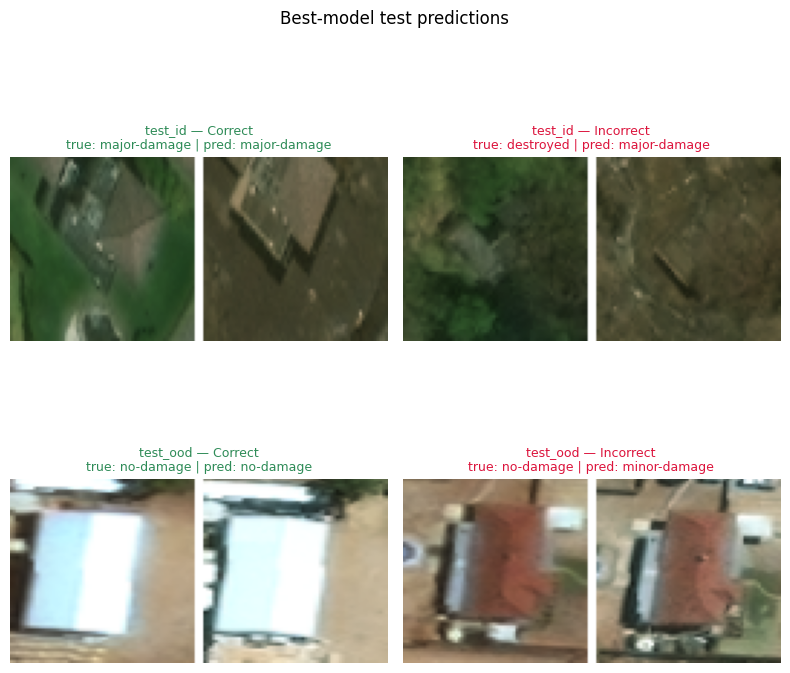

In [14]:
# One correct and one incorrect PRE | POST prediction from each held-out test split.
TEST_SPLITS = ['test_id', 'test_ood']
examples_by_split = {}
model.eval()
with torch.no_grad():
    for split in TEST_SPLITS:
        view_dataset = datasets[split]
        view_loader = DataLoader(view_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=amp_enabled)
        correct = incorrect = None
        offset = 0
        for pre, post, labels in view_loader:
            pre_device, post_device = pre.to(device, non_blocking=True), post.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                predictions = model(pre_device, post_device).argmax(1).cpu().numpy()
            for local_index, (true_label, predicted_label) in enumerate(zip(labels.numpy(), predictions)):
                example = (offset + local_index, int(true_label), int(predicted_label))
                if true_label == predicted_label and correct is None:
                    correct = example
                elif true_label != predicted_label and incorrect is None:
                    incorrect = example
            offset += len(labels)
            if correct is not None and incorrect is not None:
                break
        examples_by_split[split] = (view_dataset, correct, incorrect)

fig, axes = plt.subplots(2, 2, figsize=(8, 8), squeeze=False)
for row_index, split in enumerate(TEST_SPLITS):
    view_dataset, correct, incorrect = examples_by_split[split]
    pre_images, post_images = view_dataset.arrays()
    for column_index, (kind, example, color) in enumerate([('Correct', correct, 'seagreen'), ('Incorrect', incorrect, 'crimson')]):
        axis = axes[row_index, column_index]
        axis.axis('off')
        if example is None:
            axis.set_title(f'{split} — no {kind.lower()} example found', color=color)
            continue
        sample_index, true_label, predicted_label = example
        patch_row = view_dataset.rows[sample_index]
        separator = np.full((pre_images.shape[1], 3, 3), 255, np.uint8)
        pair = np.concatenate([np.asarray(pre_images[patch_row]), separator, np.asarray(post_images[patch_row])], axis=1)
        axis.imshow(pair)
        axis.set_title(f'{split} — {kind}\ntrue: {CLASSES[true_label]} | pred: {CLASSES[predicted_label]}', color=color, fontsize=9)
    axes[row_index, 0].set_ylabel(f'{split}\nPRE | POST', fontsize=10)
fig.suptitle('Best-model test predictions', y=.98)
fig.tight_layout()
plt.show()

### 4.3 Test-ID versus wildfire test-OOD

Aggregate scores, class-wise F1, and row-normalised confusion matrices, side by side for the in-distribution and wildfire test sets. Macro-F1 matters most here because the damage classes are imbalanced; the normalised confusion matrices show which true classes shift most when the domain changes.

C:\Users\bhvns\AppData\Local\Temp\ipykernel_6896\568176020.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, .96, .95))


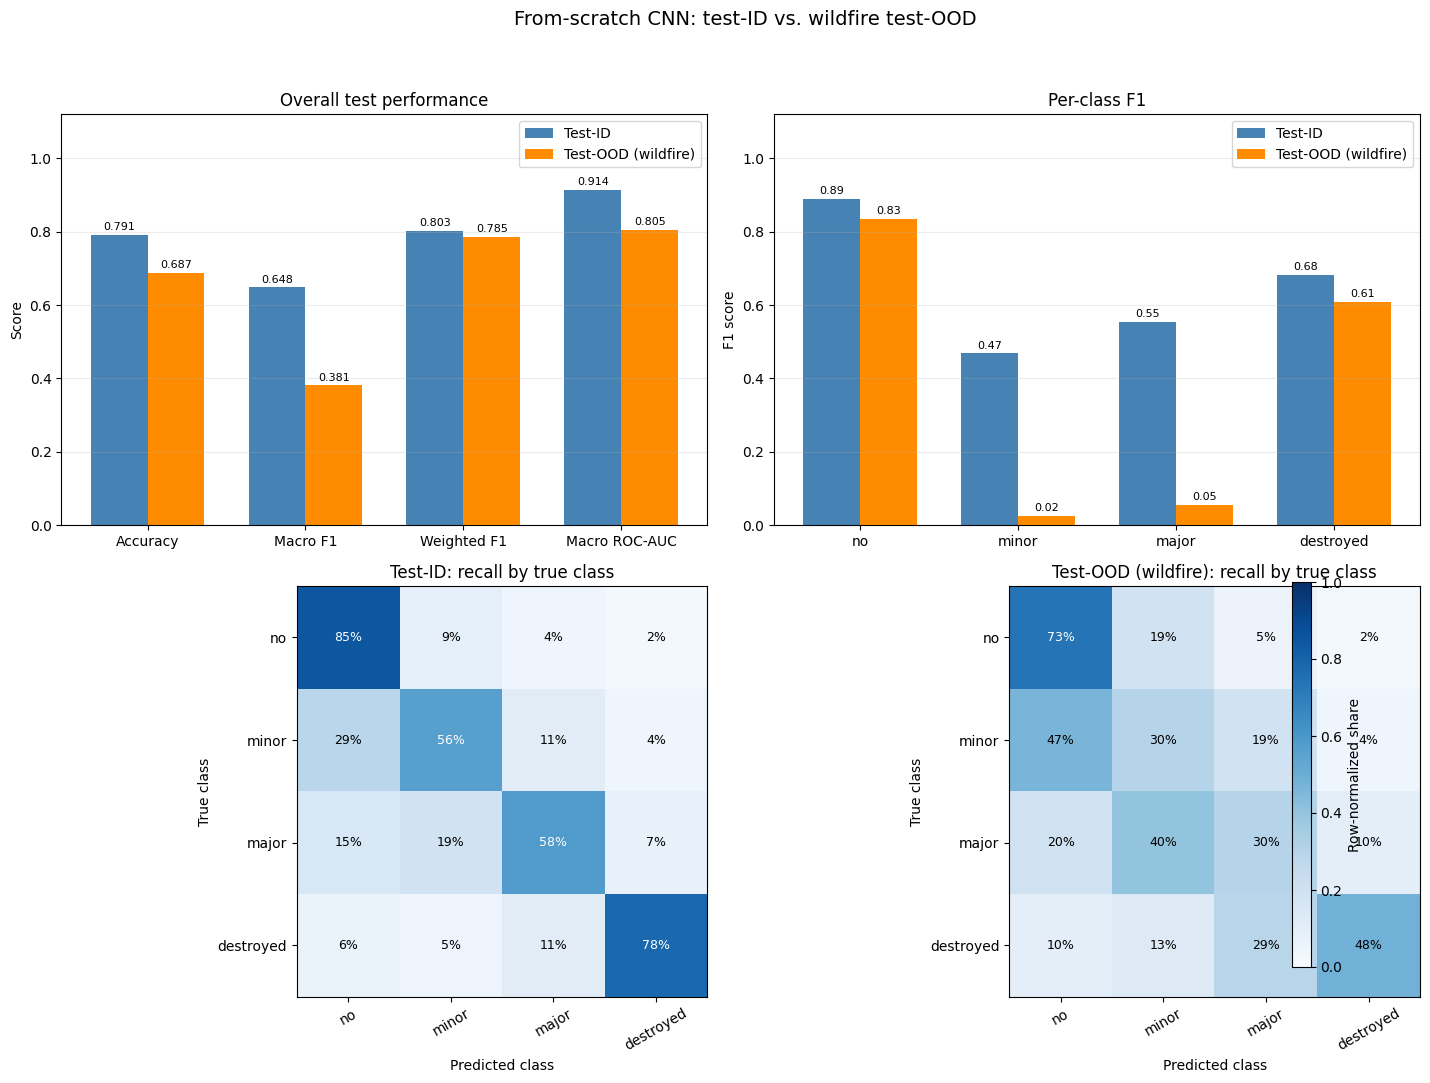

Saved comparison plots: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-scratch\test_set_comparison.png


In [16]:
# Test-set comparison: overall performance, class-wise F1, and error patterns.
overall_plot = pd.read_csv(OUTPUT_DIR / 'results_overall.csv')
per_class_plot = pd.read_csv(OUTPUT_DIR / 'results_per_class.csv')
confusion_plot = pd.read_csv(OUTPUT_DIR / 'confusion_matrices.csv')
TEST_SPLITS = ['test_id', 'test_ood']
TEST_NAMES = {'test_id': 'Test-ID', 'test_ood': 'Test-OOD (wildfire)'}
COLORS = {'test_id': 'steelblue', 'test_ood': 'darkorange'}
PLOT_CLASSES = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Overall metrics: macro-F1 and ROC-AUC are especially informative under class imbalance.
metric_columns = ['accuracy', 'macro_F1', 'weighted_F1', 'macro_ROC_AUC']
metric_labels = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro ROC-AUC']
metric_table = overall_plot.set_index('split').reindex(TEST_SPLITS)
x = np.arange(len(metric_columns)); width = .36
for offset, split in [(-width / 2, 'test_id'), (width / 2, 'test_ood')]:
    values = metric_table.loc[split, metric_columns].to_numpy(float)
    bars = axes[0, 0].bar(x + offset, values, width, label=TEST_NAMES[split], color=COLORS[split])
    axes[0, 0].bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
axes[0, 0].set(xticks=x, xticklabels=metric_labels, ylim=(0, 1.12), ylabel='Score', title='Overall test performance')
axes[0, 0].legend(); axes[0, 0].grid(axis='y', alpha=.25)

# Per-class F1 shows which damage levels drive any test-ID to OOD gap.
f1_table = per_class_plot[per_class_plot.split.isin(TEST_SPLITS)].pivot(index='class', columns='split', values='f1').reindex(PLOT_CLASSES)
x = np.arange(len(PLOT_CLASSES))
for offset, split in [(-width / 2, 'test_id'), (width / 2, 'test_ood')]:
    bars = axes[0, 1].bar(x + offset, f1_table[split], width, label=TEST_NAMES[split], color=COLORS[split])
    axes[0, 1].bar_label(bars, fmt='%.2f', padding=2, fontsize=8)
axes[0, 1].set(xticks=x, xticklabels=[name.replace('-damage', '') for name in PLOT_CLASSES], ylim=(0, 1.12), ylabel='F1 score', title='Per-class F1')
axes[0, 1].legend(); axes[0, 1].grid(axis='y', alpha=.25)

# Row-normalized confusion matrices compare the model's class-specific error modes.
for axis, split in zip(axes[1], TEST_SPLITS):
    matrix = confusion_plot[confusion_plot.split.eq(split)].set_index('true_class').reindex(PLOT_CLASSES)[PLOT_CLASSES].to_numpy(float)
    normalized = np.divide(matrix, matrix.sum(axis=1, keepdims=True), out=np.zeros_like(matrix), where=matrix.sum(axis=1, keepdims=True) != 0)
    image = axis.imshow(normalized, cmap='Blues', vmin=0, vmax=1)
    for row_index in range(len(PLOT_CLASSES)):
        for column_index in range(len(PLOT_CLASSES)):
            color = 'white' if normalized[row_index, column_index] > .55 else 'black'
            axis.text(column_index, row_index, f'{normalized[row_index, column_index]:.0%}', ha='center', va='center', color=color, fontsize=9)
    axis.set(xticks=np.arange(len(PLOT_CLASSES)), yticks=np.arange(len(PLOT_CLASSES)), xticklabels=[name.replace('-damage', '') for name in PLOT_CLASSES], yticklabels=[name.replace('-damage', '') for name in PLOT_CLASSES], xlabel='Predicted class', ylabel='True class', title=f'{TEST_NAMES[split]}: recall by true class')
    axis.tick_params(axis='x', labelrotation=30)
colorbar_axis = fig.add_axes([.89, .12, .018, .29])
fig.colorbar(image, cax=colorbar_axis, label='Row-normalized share')
fig.suptitle('From-scratch CNN: test-ID vs. wildfire test-OOD', fontsize=14, y=.98)
fig.subplots_adjust(top=.89, right=.84, wspace=.28, hspace=.36)
comparison_plot_path = OUTPUT_DIR / 'test_set_comparison.png'
fig.savefig(comparison_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved comparison plots:', comparison_plot_path)

### 4.4 Discussion

Read the figures above together:

- **Overall gap.** Compare macro-F1 on `test_id` and `test_ood`. A large drop on the wildfire set indicates the from-scratch features do not transfer across disaster types; a small drop indicates the change signal it learned is fairly domain-general.
- **Which classes move.** The per-class F1 bars and the row-normalised confusion matrices show whether the degradation is concentrated in the rarer `major-damage` / `destroyed` classes or spread evenly.
- **Against the pretrained model.** The matching ResNet-18 notebook reports the same metrics on the same splits. Any consistent advantage there — especially on the OOD set — is attributable to ImageNet pretraining, since the data, splits, and evaluation are held fixed.

## Outputs to keep

The principal artifact is `work-scratch/checkpoints/best.pt`, selected by validation macro-F1. The same directory also holds the resumable `last.pt`, the epoch history, overall and per-class metric CSVs, confusion matrices, the learning-curve and comparison figures, and `run_config.json`.